## Import Packages

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
import plotly

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, recall_score, accuracy_score, f1_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)


In [2]:
from sklearn import set_config

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
set_config(transform_output='pandas')

print('All core packages imported successfully.')

d:\Churn modelling\churn_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All core packages imported successfully.


In [3]:
try:
    import dagshub
    dagshub.init(repo_owner='Ankitkumar1141', repo_name='Churn-modelling', mlflow=True)
    print('DagsHub initialized successfully.')
except Exception as e:
    print(f'[DagsHub Notice] {e}')


Accessing as Ankitkumar1141

Initialized MLflow to track repo "Ankitkumar1141/Churn-modelling"

Repository Ankitkumar1141/Churn-modelling initialized!

DagsHub initialized successfully.


In [4]:
try:
    import mlflow
    mlflow.set_tracking_uri('https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow')
    mlflow.set_experiment('Experiment 4 - Model Selection')
    print('MLflow tracking active on DagsHub.')
except Exception as e:
    print(f'[MLflow Notice] {e}')


2026/09/30 08:55:48 INFO mlflow.tracking.fluent: Experiment with name 'Experiment 4 - Model Selection' does not exist. Creating a new experiment.


MLflow tracking active on DagsHub.


## Load the Preprocessed Data

In [5]:
df = pd.read_csv('preprocessed.csv')
print('Loaded dataset shape:', df.shape)
df.head(3)


Loaded dataset shape: (10000, 37)


,customer_id,name,gender,age,salary,location_id,churned,account_id,tenure,balance,...,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female,geo_france,geo_germany,geo_spain,geo_uk,geo_usa
0,15634602,Hargrave,female,42,101348.88,2,1,A15634602SID,2,NaN,...,1,0,0.750000,0,1,1,0,0,0,0
1,15647311,Hill,female,41,112542.58,6,0,A15647311SID,1,83807.86,...,1,0,0.416667,0,1,0,0,0,0,1
2,15619304,Onio,female,42,113931.57,4,1,A15619304SID,8,159660.80,...,0,0,0.583333,0,1,0,0,0,1,0


## Exploratory Checks

In [6]:
df.dtypes

customer_id                  int64
name                        object
gender                      object
age                          int64
salary                     float64
location_id                  int64
churned                      int64
account_id                  object
tenure                       int64
balance                    float64
num_products                 int64
has_credit_card              int64
is_active                    int64
geography                   object
age_group                   object
salary_bracket              object
tenure_group                object
has_balance                  int64
churn_label                 object
has_credit_card_label       object
is_active_label             object
balance_to_salary          float64
balance_per_product        float64
age_when_joined              int64
products_per_tenure        float64
is_senior_risk               int64
is_extreme_product_risk      int64
is_single_product            int64
inactive_senior     

In [7]:
df.isna().sum().sort_values(ascending=False).head(5)

balance        3617
name              0
gender            0
age               0
customer_id       0
dtype: int64

In [8]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [9]:
print(df['churned'].value_counts())
churn_rate = df['churned'].mean()
print('\nChurn rate: {:.2%}'.format(churn_rate))


churned
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


## Drop Unnecessary Columns

In [10]:
drop_columns = [
    'has_balance',
    'products_per_tenure',
    'has_credit_card',
    'geo_france', 'geo_uk', 'geo_usa', 'geo_spain', 'geo_germany',
    'tenure', 'salary',
    'customer_id',
    'account_id', 'name', 'location_id',
    'age_when_joined', 'age',
    'churn_label',
    'has_credit_card_label',
    'is_active_label',
]

df = df.drop(columns=drop_columns)
print('Shape after dropping columns:', df.shape)
df.head(3)


Shape after dropping columns: (10000, 18)


,gender,churned,balance,num_products,is_active,geography,age_group,salary_bracket,tenure_group,balance_to_salary,balance_per_product,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female
0,female,1,NaN,1,1,france,36-45,high,new (0-2),0.000000,0.000000,0,0,1,0,0.750000,0,1
1,female,0,83807.86,1,1,usa,36-45,high,new (0-2),0.744670,83807.860000,0,0,1,0,0.416667,0,1
2,female,1,159660.80,3,0,uk,36-45,high,veteran (8-10),1.401362,53220.266667,0,1,0,0,0.583333,0,1


In [11]:
missing_cols = df.isna().any(axis=0).loc[lambda x: x].index.tolist()
print('Columns with missing values:', missing_cols)

Columns with missing values: ['balance']


In [12]:
pct_missing_rows = df.isna().any(axis=1).mean().round(4) * 100
print(f'Rows with missing values: {pct_missing_rows:.2f}%  ({df.isna().any(axis=1).sum():,} rows)')

Rows with missing values: 36.17%  (3,617 rows)


## Train / Test Split

In [13]:
X = df.drop(columns='churned')
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print('Train size : {:,}  |  churn rate: {:.2%}'.format(X_train.shape[0], y_train.mean()))
print('Test  size : {:,}  |  churn rate: {:.2%}'.format(X_test.shape[0], y_test.mean()))


Train size : 8,000  |  churn rate: 20.38%
Test  size : 2,000  |  churn rate: 20.35%


In [14]:
print('Train shape:', X_train.shape)
print('Test  shape:', X_test.shape)
print('Missing in train (balance only):\n', X_train.isna().sum()[X_train.isna().sum() > 0])


Train shape: (8000, 17)
Test  shape: (2000, 17)
Missing in train (balance only):
 balance    2891
dtype: int64


## Column Type Identification

In [15]:
numeric_cols     = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
binary_cols      = [c for c in numeric_cols if X[c].nunique() == 2]
scale_cols       = [c for c in numeric_cols if c not in binary_cols]

print('Numeric (to scale) :', scale_cols)
print('Binary pass-thru   :', binary_cols)
print('Categorical OHE    :', categorical_cols)


Numeric (to scale) : ['balance', 'num_products', 'balance_to_salary', 'balance_per_product', 'engagement_score']
Binary pass-thru   : ['is_active', 'is_senior_risk', 'is_extreme_product_risk', 'is_single_product', 'inactive_senior', 'high_risk_inactive', 'is_female']
Categorical OHE    : ['gender', 'geography', 'age_group', 'salary_bracket', 'tenure_group']


## Preprocessing Pipeline

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scale',          MinMaxScaler(), scale_cols),
        ('nominal_encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform='pandas')

knn_imputer = KNNImputer(n_neighbors=10)

In [17]:
# Sanity check -- fit on train, transform test using flat steps
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn_imputer',  knn_imputer),
])

In [18]:
X_train_trans = base_pipeline.fit_transform(X_train)
X_test_trans  = base_pipeline.transform(X_test)

print('X_train transformed shape:', X_train_trans.shape)
print('X_test  transformed shape:', X_test_trans.shape)


X_train transformed shape: (8000, 28)
X_test  transformed shape: (2000, 28)


### Class Imbalance Handling

In [19]:
sampler = RandomUnderSampler(random_state=42)

# Apply resampling to training data only (never to test set)
X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_trans, y_train)

In [20]:
print('Before resampling — Train shape:', X_train_trans.shape)
print('Before resampling — Class distribution:')
print(y_train.value_counts())
print()
print('After  resampling — Train shape:', X_train_resampled.shape)
print('After  resampling — Class distribution:')
print(y_train_resampled.value_counts())


Before resampling — Train shape: (8000, 28)
Before resampling — Class distribution:
churned
0    6370
1    1630
Name: count, dtype: int64

After  resampling — Train shape: (3260, 28)
After  resampling — Class distribution:
churned
0    1630
1    1630
Name: count, dtype: int64


## Model Selection with Optuna

Multi-model spot-check over **7 model families** using **Optuna Bayesian optimisation**.  
Each trial is logged as a nested MLflow run.  
**Primary metric: ROC-AUC** (maximised).  

| Model | Key Hyperparameters |
|---|---|
| LR | `C` |
| DT | `max_depth` |
| KNN | `n_neighbors` |
| RF | `n_estimators`, `max_depth` |
| XGB | `n_estimators`, `learning_rate`, `max_depth` |
| LGBM | `n_estimators`, `learning_rate`, `max_depth` |
| SVM | `C` |


In [21]:
def objective(trial):
    with mlflow.start_run(nested=True):
        model_name = trial.suggest_categorical(
            'model', ['LR', 'DT', 'KNN', 'RF', 'XGB', 'LGBM', 'SVM']
        )

        if model_name == 'LR':
            C_lr = trial.suggest_float('C_lr', 1e-3, 10.0, log=True)
            model = LogisticRegression(C=C_lr, max_iter=500, random_state=42)

        elif model_name == 'DT':
            max_depth_dt = trial.suggest_int('max_depth_dt', 3, 20)
            model = DecisionTreeClassifier(max_depth=max_depth_dt, random_state=42)

        elif model_name == 'KNN':
            n_neighbors_knn = trial.suggest_int('n_neighbors_knn', 3, 15)
            model = KNeighborsClassifier(n_neighbors=n_neighbors_knn, n_jobs=-1)

        elif model_name == 'RF':
            n_estimators_rf = trial.suggest_int('n_estimators_rf', 10, 200)
            max_depth_rf    = trial.suggest_int('max_depth_rf', 2, 20)
            model = RandomForestClassifier(
                n_estimators=n_estimators_rf,
                max_depth=max_depth_rf,
                random_state=42,
                n_jobs=-1,
            )

        elif model_name == 'XGB':
            n_estimators_xgb    = trial.suggest_int('n_estimators_xgb', 10, 200)
            learning_rate_xgb   = trial.suggest_float('learning_rate_xgb', 0.01, 0.5)
            max_depth_xgb       = trial.suggest_int('max_depth_xgb', 2, 20)
            model = XGBClassifier(
                n_estimators=n_estimators_xgb,
                learning_rate=learning_rate_xgb,
                max_depth=max_depth_xgb,
                random_state=42,
                n_jobs=-1,
                verbosity=0,
            )

        elif model_name == 'LGBM':
            n_estimators_lgbm  = trial.suggest_int('n_estimators_lgbm', 10, 200)
            learning_rate_lgbm = trial.suggest_float('learning_rate_lgbm', 0.01, 0.5)
            max_depth_lgbm     = trial.suggest_int('max_depth_lgbm', 2, 20)
            model = LGBMClassifier(
                n_estimators=n_estimators_lgbm,
                learning_rate=learning_rate_lgbm,
                max_depth=max_depth_lgbm,
                random_state=42,
                n_jobs=-1,
                verbose=-1,
            )

        elif model_name == 'SVM':
            C_svm = trial.suggest_float('C_svm', 0.1, 10.0)
            model = SVC(C=C_svm, probability=True, random_state=42)

        # train on resampled data
        model.fit(X_train_resampled, y_train_resampled)

        # log model params
        mlflow.log_params(model.get_params())

        # predictions on held-out test set (full, unresampled)
        y_pred_prob = model.predict_proba(X_test_trans)[:, 1]

        # primary metric
        score = roc_auc_score(y_test, y_pred_prob)

        # log model name + metric
        mlflow.log_param('model', model_name)
        mlflow.log_metric('ROC_AUC', score)

        return score


In [22]:
# create optuna study
study = optuna.create_study(direction='maximize', study_name='model_selection')

with mlflow.start_run(run_name='Best Model') as parent:
    # optimize the objective function
    study.optimize(objective, n_trials=30, n_jobs=-1)

    # log the best parameters
    mlflow.log_params(study.best_params)

    # log the best score
    mlflow.log_metric('best_score', study.best_value)


🏃 View run learned-smelt-726 at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3/runs/41695357ca4f4c1e8e361e90d85b1970
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3
🏃 View run thundering-crane-461 at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3/runs/0582c79ebb634d96b2e7433cd79c3336
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3
🏃 View run fortunate-pig-72 at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3/runs/ffd5b40285f347a8b1ceba46afa174b7
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3
🏃 View run honorable-dog-582 at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3/runs/f53cf67703ff48549b76bb56829538a1
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3
🏃 View run orderly-eel-253 at: htt

In [23]:
# best score
study.best_value


0.8473172710460846

In [24]:
# best parameters
study.best_params


{'model': 'XGB',
 'n_estimators_xgb': 32,
 'learning_rate_xgb': 0.07724237493245067,
 'max_depth_xgb': 4}

In [25]:
# dataframe of all trials
study.trials_dataframe()


,number,value,datetime_start,datetime_complete,duration,params_C_lr,params_C_svm,params_learning_rate_lgbm,params_learning_rate_xgb,params_max_depth_dt,params_max_depth_lgbm,params_max_depth_rf,params_max_depth_xgb,params_model,params_n_estimators_lgbm,params_n_estimators_rf,params_n_estimators_xgb,params_n_neighbors_knn,state
0,0,0.842649,2026-09-30 08:58:58.668782,2026-09-30 08:59:26.212054,0 days 00:00:27.543272,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,RF,NaN,41.0,NaN,NaN,COMPLETE
1,1,0.810423,2026-09-30 08:58:58.671377,2026-09-30 09:00:43.276691,0 days 00:01:44.605314,NaN,3.908069,NaN,NaN,NaN,NaN,NaN,NaN,SVM,NaN,NaN,NaN,NaN,COMPLETE
2,2,0.796029,2026-09-30 08:58:58.671377,2026-09-30 08:59:51.305588,0 days 00:00:52.634211,NaN,9.044144,NaN,NaN,NaN,NaN,NaN,NaN,SVM,NaN,NaN,NaN,NaN,COMPLETE
3,3,0.829036,2026-09-30 08:58:58.674007,2026-09-30 08:59:58.155650,0 days 00:00:59.481643,0.020106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LR,NaN,NaN,NaN,NaN,COMPLETE
4,4,0.841153,2026-09-30 08:58:58.675419,2026-09-30 09:01:27.371445,0 days 00:02:28.696026,NaN,NaN,NaN,0.249202,NaN,NaN,NaN,3.0,XGB,NaN,NaN,92.0,NaN,COMPLETE
5,5,0.802015,2026-09-30 08:58:58.679395,2026-09-30 09:01:18.234365,0 days 00:02:19.554970,NaN,NaN,0.494069,NaN,NaN,20.0,NaN,NaN,LGBM,164.0,NaN,NaN,NaN,COMPLETE
6,6,0.830111,2026-09-30 08:58:58.679395,2026-09-30 09:00:02.078914,0 days 00:01:03.399519,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,DT,NaN,NaN,NaN,NaN,COMPLETE
7,7,0.814521,2026-09-30 08:58:58.683476,2026-09-30 09:00:03.278078,0 days 00:01:04.594602,NaN,NaN,NaN,0.425763,NaN,NaN,NaN,16.0,XGB,NaN,NaN,106.0,NaN,COMPLETE
8,8,0.802606,2026-09-30 08:58:58.683476,2026-09-30 08:59:55.497441,0 days 00:00:56.813965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KNN,NaN,NaN,NaN,13.0,COMPLETE
9,9,0.796179,2026-09-30 08:58:58.687095,2026-09-30 09:00:47.290048,0 days 00:01:48.602953,NaN,8.991559,NaN,NaN,NaN,NaN,NaN,NaN,SVM,NaN,NaN,NaN,NaN,COMPLETE


In [26]:
# model frequency across all trials
study.trials_dataframe()['params_model'].value_counts()


params_model
RF      15
SVM      3
LR       3
XGB      3
KNN      3
LGBM     2
DT       1
Name: count, dtype: int64

In [27]:
# avg scores for all tested models
avg_scores = (
    study.trials_dataframe()
    .groupby('params_model')['value']
    .mean()
    .sort_values(ascending=False)
)
print('=== Average ROC-AUC per Model Family ===')
print(avg_scores)


=== Average ROC-AUC per Model Family ===
params_model
RF      0.839211
XGB     0.834330
DT      0.830111
LGBM    0.814655
LR      0.807670
KNN     0.801957
SVM     0.800877
Name: value, dtype: float64


## Optimisation History

In [45]:
import plotly
from plotly import __version__ as plotly_version

In [47]:
python -c "import plotly; print(plotly.__version__)"

SyntaxError: invalid syntax (2476746620.py, line 1)

In [46]:
# optimization history plot
optuna.visualization.plot_optimization_history(study)


ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

In [ ]:
# partial coord plot -- model family comparison
optuna.visualization.plot_parallel_coordinate(study, params=['model'])


## Evaluate Best Model on Test Set

In [30]:
# Identify winning model family from study
best_model_name = study.best_params['model']
print('Best model family:', best_model_name)
print('Best ROC-AUC     :', round(study.best_value, 4))


Best model family: XGB
Best ROC-AUC     : 0.8473


In [31]:
# Rebuild best model using best params from study
best_params = study.best_params.copy()
best_params.pop('model')   # remove the 'model' key — remaining are hyperparams

if best_model_name == 'LR':
    best_model = LogisticRegression(C=best_params.get('C_lr', 1.0), max_iter=500, random_state=42)

elif best_model_name == 'DT':
    best_model = DecisionTreeClassifier(max_depth=best_params.get('max_depth_dt', 10), random_state=42)

elif best_model_name == 'KNN':
    best_model = KNeighborsClassifier(n_neighbors=best_params.get('n_neighbors_knn', 5), n_jobs=-1)

elif best_model_name == 'RF':
    best_model = RandomForestClassifier(
        n_estimators=best_params.get('n_estimators_rf', 100),
        max_depth=best_params.get('max_depth_rf', 10),
        random_state=42, n_jobs=-1,
    )

elif best_model_name == 'XGB':
    best_model = XGBClassifier(
        n_estimators=best_params.get('n_estimators_xgb', 100),
        learning_rate=best_params.get('learning_rate_xgb', 0.1),
        max_depth=best_params.get('max_depth_xgb', 6),
        random_state=42, n_jobs=-1, verbosity=0,
    )

elif best_model_name == 'LGBM':
    best_model = LGBMClassifier(
        n_estimators=best_params.get('n_estimators_lgbm', 100),
        learning_rate=best_params.get('learning_rate_lgbm', 0.1),
        max_depth=best_params.get('max_depth_lgbm', 6),
        random_state=42, n_jobs=-1, verbose=-1,
    )

elif best_model_name == 'SVM':
    best_model = SVC(C=best_params.get('C_svm', 1.0), probability=True, random_state=42)

# train on resampled data
best_model.fit(X_train_resampled, y_train_resampled)
print('Best model trained.')


Best model trained.


In [32]:
# Predictions on full train + test (pre-transformed, unresampled)
y_pred_train = best_model.predict(X_train_trans)
y_pred_test  = best_model.predict(X_test_trans)
y_prob_train = best_model.predict_proba(X_train_trans)[:, 1]
y_prob_test  = best_model.predict_proba(X_test_trans)[:, 1]

print(f'Train accuracy : {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test  accuracy : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Train recall   : {recall_score(y_train, y_pred_train):.4f}')
print(f'Test  recall   : {recall_score(y_test, y_pred_test):.4f}')
print(f'Train ROC-AUC  : {roc_auc_score(y_train, y_prob_train):.4f}')
print(f'Test  ROC-AUC  : {roc_auc_score(y_test, y_prob_test):.4f}')


Train accuracy : 0.7834
Test  accuracy : 0.7775
Train recall   : 0.7313
Test  recall   : 0.7224
Train ROC-AUC  : 0.8503
Test  ROC-AUC  : 0.8473


In [33]:
print('\n=== Classification Report (Test Set) ===')
print(classification_report(y_test, y_pred_test, target_names=['Stayed', 'Churned']))



=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Stayed       0.92      0.79      0.85      1593
     Churned       0.47      0.72      0.57       407

    accuracy                           0.78      2000
   macro avg       0.69      0.76      0.71      2000
weighted avg       0.83      0.78      0.79      2000



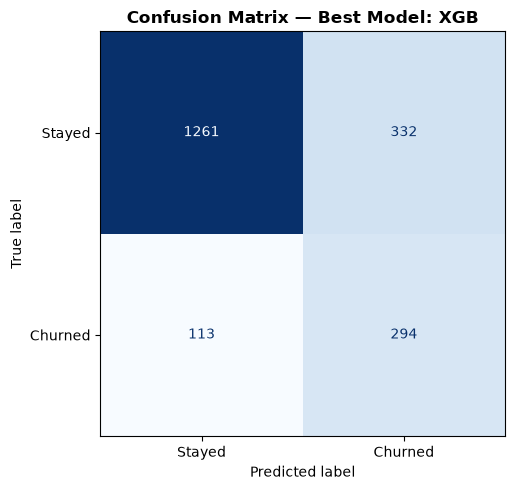

In [34]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Best Model: {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()


## Cross-Validation

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc'  : 'roc_auc',
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
}


In [36]:
# Full pipeline: preprocessor + KNN imputer + resampler + best classifier
cv_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn_imputer',  KNNImputer(n_neighbors=10)),
    ('sampler',      RandomUnderSampler(random_state=42)),
    ('classifier',   best_model),
])

cv_results = cross_validate(
    cv_pipeline,
    X_train,       # raw X_train — pipeline handles everything inside each fold
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=1,
)

results_df = pd.DataFrame(cv_results)
results_df


,fit_time,score_time,test_roc_auc,test_recall,test_precision,test_f1,test_accuracy
0,2.879313,1.316068,0.837818,0.723926,0.487603,0.582716,0.788750
1,2.465147,1.308001,0.851386,0.763804,0.444643,0.562077,0.757500
2,2.364286,1.439507,0.838300,0.702454,0.449902,0.548503,0.764375
3,2.370602,1.380736,0.815453,0.684049,0.444223,0.538647,0.761250
4,2.278886,1.438446,0.841065,0.714724,0.476483,0.571779,0.781875


In [37]:
print('=== CV Summary (5-Fold Stratified) ===')
print(f"Mean CV ROC-AUC  : {results_df['test_roc_auc'].mean():.4f} +/- {results_df['test_roc_auc'].std():.4f}")
print(f"Mean CV Recall   : {results_df['test_recall'].mean():.4f} +/- {results_df['test_recall'].std():.4f}")
print(f"Mean CV Precision: {results_df['test_precision'].mean():.4f} +/- {results_df['test_precision'].std():.4f}")
print(f"Mean CV F1       : {results_df['test_f1'].mean():.4f} +/- {results_df['test_f1'].std():.4f}")
print(f"Mean CV Accuracy : {results_df['test_accuracy'].mean():.4f} +/- {results_df['test_accuracy'].std():.4f}")


=== CV Summary (5-Fold Stratified) ===
Mean CV ROC-AUC  : 0.8368 +/- 0.0131
Mean CV Recall   : 0.7178 +/- 0.0297
Mean CV Precision: 0.4606 +/- 0.0201
Mean CV F1       : 0.5607 +/- 0.0176
Mean CV Accuracy : 0.7707 +/- 0.0137


## Log Experiment to MLflow

In [38]:
try:
    with mlflow.start_run(run_name=f'Best Model — {best_model_name}'):
        mlflow.log_param('experiment_type',    'Model Selection')
        mlflow.log_param('imbalance_strategy', 'RandomUnderSampler')
        mlflow.log_param('imputer',            'KNNImputer(n_neighbors=10)')
        mlflow.log_param('best_model',         best_model_name)
        mlflow.log_param('dataset_rows',       X.shape[0])
        mlflow.log_param('dataset_features',   X.shape[1])
        mlflow.log_params(best_model.get_params())

        mlflow.log_metric('training_accuracy', accuracy_score(y_train, y_pred_train))
        mlflow.log_metric('training_recall',   recall_score(y_train, y_pred_train))
        mlflow.log_metric('training_roc_auc',  roc_auc_score(y_train, y_prob_train))
        mlflow.log_metric('test_accuracy',     accuracy_score(y_test, y_pred_test))
        mlflow.log_metric('test_recall',       recall_score(y_test, y_pred_test))
        mlflow.log_metric('test_precision',    precision_score(y_test, y_pred_test))
        mlflow.log_metric('test_f1',           f1_score(y_test, y_pred_test))
        mlflow.log_metric('test_roc_auc',      roc_auc_score(y_test, y_prob_test))
        mlflow.log_metric('cv_mean_recall',    results_df['test_recall'].mean())
        mlflow.log_metric('cv_mean_roc_auc',   results_df['test_roc_auc'].mean())
        mlflow.log_metric('cv_mean_f1',        results_df['test_f1'].mean())

        for i, s in enumerate(results_df['test_roc_auc']):
            mlflow.log_metric('cv_roc_auc_fold', s, step=i)
        for i, s in enumerate(results_df['test_recall']):
            mlflow.log_metric('cv_recall_fold', s, step=i)

    print('Experiment logged to MLflow.')
except Exception as e:
    print(f'[MLflow Notice] {e}')


🏃 View run Best Model — XGB at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3/runs/2aee7be5803245a288cd041f80187061
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/3
Experiment logged to MLflow.


## Final Summary

In [40]:
summary = pd.DataFrame({
    'Metric': [
        'Test ROC-AUC', 'Test Recall', 'Test Precision', 'Test F1', 'Test Accuracy',
        'CV ROC-AUC (mean)', 'CV Recall (mean)', 'CV F1 (mean)', 'CV Accuracy (mean)',
    ],
    f'Exp 4: Model Selection ({best_model_name} + UnderSample)': [
        round(roc_auc_score(y_test, y_prob_test),           4),
        round(recall_score(y_test, y_pred_test),            4),
        round(precision_score(y_test, y_pred_test),         4),
        round(f1_score(y_test, y_pred_test),                4),
        round(accuracy_score(y_test, y_pred_test),          4),
        round(results_df['test_roc_auc'].mean(),            4),
        round(results_df['test_recall'].mean(),             4),
        round(results_df['test_f1'].mean(),                 4),
        round(results_df['test_accuracy'].mean(),           4),
    ]
})
summary


,Metric,Exp 4: Model Selection (XGB + UnderSample)
0,Test ROC-AUC,0.8473
1,Test Recall,0.7224
2,Test Precision,0.4696
3,Test F1,0.5692
4,Test Accuracy,0.7775
5,CV ROC-AUC (mean),0.8368
6,CV Recall (mean),0.7178
7,CV F1 (mean),0.5607
8,CV Accuracy (mean),0.7707


In [42]:
print(f'>>> Best model: {best_model_name}  |  Optuna best ROC-AUC: {study.best_value:.4f}')
print('>>> Average ROC-AUC per model family (ranked):')
print(avg_scores.to_string())
print()

>>> Best model: XGB  |  Optuna best ROC-AUC: 0.8473
>>> Average ROC-AUC per model family (ranked):
params_model
RF      0.839211
XGB     0.834330
DT      0.830111
LGBM    0.814655
LR      0.807670
KNN     0.801957
SVM     0.800877

